In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import lightgbm
from lightgbm import LGBMClassifier
from tree_influence.explainers import BoostIn
import pandas as pd 
import sklearn 

In [2]:
# load german credit data 
data = pd.read_csv('german_credit_data.csv', index_col=0)

# encode binary value 
data["Risk"] = data["Risk"].replace({'good': 0, 'bad': 1})

# check counts 
data['Risk'].value_counts(dropna=False)

/var/folders/l5/1_f10tdn2tq4r52l8yvcrf640000gn/T/ipykernel_66213/1866174846.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Risk"] = data["Risk"].replace({'good': 0, 'bad': 1})


Risk
0    700
1    300
Name: count, dtype: int64

In [3]:
# categorical columns have type 'object', should transform in category pandas dtype for LightGBM
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
for c in cat_cols: 
    data[c] = data[c].astype('category')

# check 
print(data.dtypes)

Age                    int64
Sex                 category
Job                    int64
Housing             category
Saving accounts     category
Checking account    category
Credit amount          int64
Duration               int64
Purpose             category
Risk                   int64
dtype: object


In [12]:
y = data['Risk']
X = pd.get_dummies(data.drop(columns="Risk"), drop_first=True)  # everything except risk + categorical in dummies

# train/ test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y) # stratify=y pour garder la même proportion de bon et mauvais 

# convert to numpy
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

## Training

In [13]:
# train GBDT model
model = LGBMClassifier().fit(X_train_np, y_train_np)

# fit influence estimator
explainer = BoostIn().fit(model, X_train_np, y_train_np)

# estimate training influences on each test instance
influence = explainer.get_local_influence(X_test_np, y_test_np)  # shape=(no. train, no. test)

# extract influence values for the first test instance
values = influence[:, 0]  # retrieve first column, meaning influence of each training example on first test

# sort training examples from:
# - most positively influential (decreases loss of the test instance the most), to
# - most negatively influential (increases loss of the test instance the most)
training_idxs = np.argsort(values)[::-1]

[LightGBM] [Info] Number of positive: 240, number of negative: 560
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Visualisation of top 5 most influential points for a given test point

In [14]:
print("Tested client profile :")
print(X_test.iloc[0])
print("True label:", y_test.iloc[0])
print("Model prediction:", model.predict(X_test_np[[0]])[0])
print("Predicted probability:", model.predict_proba(X_test_np[[0]])[0,1])

Tested client profile :
Age                               66
Job                                0
Credit amount                   1480
Duration                          12
Sex_male                        True
Housing_own                    False
Housing_rent                   False
Saving accounts_moderate       False
Saving accounts_quite rich      True
Saving accounts_rich           False
Checking account_moderate      False
Checking account_rich           True
Purpose_car                     True
Purpose_domestic appliances    False
Purpose_education              False
Purpose_furniture/equipment    False
Purpose_radio/TV               False
Purpose_repairs                False
Purpose_vacation/others        False
Name: 774, dtype: object
True label: 0
Model prediction: 0
Predicted probability: 0.0727594706516854


/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
print("Influence matrix :", influence.shape)
print("Top 5 proponent examples:", training_idxs[:5])
print("Top 5 oponont examples:", training_idxs[-5:])

# Et regarder les vrais exemples concernés :
data.iloc[training_idxs[:5]]

Influence matrix : (800, 200)
Top 5 proponent examples: [ 93 397 467 206 460]
Top 5 oponont examples: [ 56 340  69 618 313]


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
93,20,male,2,rent,NaN,rich,3617,24,furniture/equipment,0
397,46,male,2,own,little,little,2348,36,furniture/equipment,0
467,32,male,2,own,NaN,NaN,7238,48,radio/TV,0
206,43,male,2,own,little,NaN,1935,12,furniture/equipment,0
460,37,male,2,own,little,little,3620,36,furniture/equipment,0


/var/folders/l5/1_f10tdn2tq4r52l8yvcrf640000gn/T/ipykernel_66213/1850781047.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Risk"] = data["Risk"].replace({"good": 0, "bad": 1})
/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was

N = 750   Pearson r = +0.390   (p = 1.34e-28)


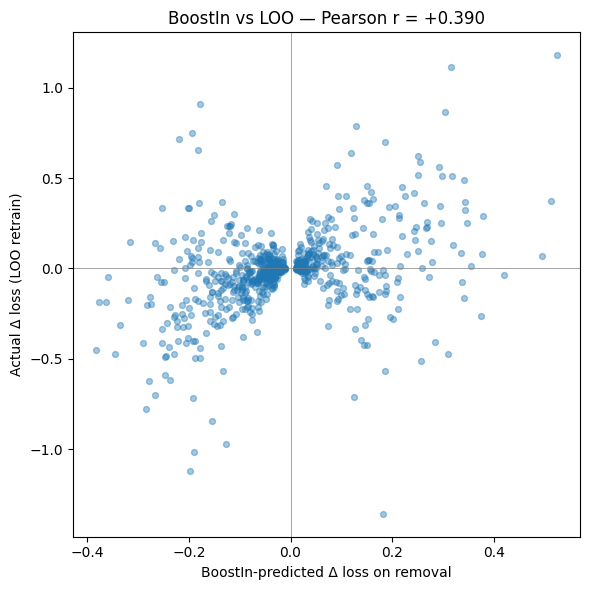

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from tree_influence.explainers import BoostIn

# --- 1. Données ---
data = pd.read_csv("german_credit_data.csv", index_col=0, na_values=["NA"])
data["Risk"] = data["Risk"].replace({"good": 0, "bad": 1})
y = data["Risk"]
X = pd.get_dummies(data.drop(columns="Risk"), drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)
X_tr_np, X_te_np = X_tr.to_numpy(), X_te.to_numpy()
y_tr_np, y_te_np = y_tr.to_numpy(), y_te.to_numpy()

# --- 2. Modèle de base + losses de référence ---
MODEL_PARAMS = dict(n_estimators=100, random_state=1,
                    deterministic=True, verbose=-1)

def per_sample_logloss(model, X, y):
    p = model.predict_proba(X)
    return -np.log(np.clip(p[np.arange(len(y)), y], 1e-12, 1.0))

base_model = LGBMClassifier(**MODEL_PARAMS).fit(X_tr_np, y_tr_np)
base_losses = per_sample_logloss(base_model, X_te_np, y_te_np)

# --- 3. Choix des 50 tests + BoostIn ---
N_TEST, K = 50, 15
rng = np.random.default_rng(0)
test_idx = rng.choice(len(X_te_np), size=N_TEST, replace=False)

explainer = BoostIn().fit(base_model, X_tr_np, y_tr_np)
influence = explainer.get_local_influence(X_te_np[test_idx], y_te_np[test_idx])
# shape : (n_train, N_TEST)

# --- 4. LOO retraining sur les top-k de chaque test ---
predicted, actual = [], []

for t, te_i in enumerate(test_idx):
    col = influence[:, t]
    topk = np.argsort(np.abs(col))[-K:]              # |influence| → on garde proponents ET opponents

    for tr_i in topk:
        mask = np.ones(len(X_tr_np), dtype=bool)
        mask[tr_i] = False
        m_loo = LGBMClassifier(**MODEL_PARAMS).fit(X_tr_np[mask], y_tr_np[mask])
        loo_loss = per_sample_logloss(m_loo, X_te_np[[te_i]], y_te_np[[te_i]])[0]

        predicted.append(col[tr_i])                  # signe à valider, voir ci-dessous
        actual.append(loo_loss - base_losses[te_i])

predicted = np.array(predicted)
actual = np.array(actual)

# --- 5. Pearson + plot ---
r, p = pearsonr(predicted, actual)
print(f"N = {len(predicted)}   Pearson r = {r:+.3f}   (p = {p:.2e})")

plt.figure(figsize=(6, 6))
plt.scatter(predicted, actual, alpha=0.4, s=18)
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("BoostIn-predicted Δ loss on removal")
plt.ylabel("Actual Δ loss (LOO retrain)")
plt.title(f"BoostIn vs LOO — Pearson r = {r:+.3f}")
plt.tight_layout(); plt.show()
